# MobileNet V2

In [1]:
import os
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
import torchaudio
from torch.utils.data import Dataset, DataLoader
from torchvision import models, transforms
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
import matplotlib.pyplot as plt
from tqdm import tqdm

# Set device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f'Using device: {device}')

Using device: cuda


In [2]:
print(f'PyTorch Version: {torch.__version__}')
print(f'CUDA Available: {torch.cuda.is_available()}')
print(f'CUDA Version: {torch.version.cuda}')
if torch.cuda.is_available():
    print(f'Device Name: {torch.cuda.get_device_name(0)}')
else:
    print('CUDA is not available. You might have the CPU-only version of PyTorch installed.')

PyTorch Version: 2.5.1+cu121
CUDA Available: True
CUDA Version: 12.1
Device Name: NVIDIA GeForce RTX 3050 6GB Laptop GPU


In [3]:
class MelSpectrogramDataset(Dataset):
    def __init__(self, file_paths, labels, transform=None):
        self.file_paths = file_paths
        self.labels = labels
        self.transform = transform

    def __len__(self):
        return len(self.file_paths)

    def __getitem__(self, idx):
        npy_path = self.file_paths[idx]
        label = self.labels[idx]

        # Load Mel Spectrogram
        mel_spec = np.load(npy_path)
        if mel_spec.min() >= 0:
            mel_spec = np.log(mel_spec + 1e-9)
        mel_spec = np.nan_to_num(mel_spec, nan=0.0, posinf=0.0, neginf=-100.0)

        # Normalize to 0-1 range
        delta = mel_spec.max() - mel_spec.min()
        if delta > 1e-6:
            mel_spec = (mel_spec - mel_spec.min()) / delta
        else:
            mel_spec = np.zeros_like(mel_spec)

        # To tensor, add channel dim, repeat to 3 channels
        mel_spec = torch.from_numpy(mel_spec).float().unsqueeze(0)
        mel_spec = mel_spec.repeat(3, 1, 1)

        if self.transform:
            mel_spec = self.transform(mel_spec)

        
        return mel_spec, label

In [ ]:
# Configuration (reuse same mel_arrays directory)
DATA_DIR = r'.../mel_arrays'
BATCH_SIZE = 16
NUM_EPOCHS = 35
LEARNING_RATE = 3e-4  # good starting LR for fine-tuning

file_paths = []
labels = []
track_ids = []
classes = os.listdir(DATA_DIR)

for label in classes:
    class_dir = os.path.join(DATA_DIR, label)
    if not os.path.isdir(class_dir):
        continue
    for f in os.listdir(class_dir):
        if f.endswith('.npy'):
            file_paths.append(os.path.join(class_dir, f))
            labels.append(label)
            track_id = f.split('_seg')[0]
            track_ids.append(track_id)

le = LabelEncoder()
labels_encoded = le.fit_transform(labels)
num_classes = len(le.classes_)
print(f'Found {len(file_paths)} files across {num_classes} classes: {le.classes_}')

track_to_label = {}
for tid, lbl in zip(track_ids, labels_encoded):
    track_to_label[tid] = lbl

unique_tracks = list(track_to_label.keys())
unique_track_labels = list(track_to_label.values())

train_tracks, temp_tracks, y_train_tracks, y_temp_tracks = train_test_split(
    unique_tracks, unique_track_labels,
    test_size=0.25,
    random_state=42,
    stratify=unique_track_labels
)

val_tracks, test_tracks, y_val_tracks, y_test_tracks = train_test_split(
    temp_tracks, y_temp_tracks,
    test_size=0.4,
    random_state=42,
    stratify=y_temp_tracks
)

train_ids_set = set(train_tracks)
val_ids_set = set(val_tracks)
test_ids_set = set(test_tracks)

assert len(train_ids_set.intersection(val_ids_set)) == 0
assert len(train_ids_set.intersection(test_ids_set)) == 0
assert len(val_ids_set.intersection(test_ids_set)) == 0
print('SUCCESS: Data split verified. No song leakage between sets.')

print(f'Tracks split: Train={len(train_tracks)}, Val={len(val_tracks)}, Test={len(test_tracks)}')

train_files, val_files, test_files = [], [], []
train_labels, val_labels, test_labels = [], [], []

for fp, lbl, tid in zip(file_paths, labels_encoded, track_ids):
    if tid in train_ids_set:
        train_files.append(fp)
        train_labels.append(lbl)
    elif tid in val_ids_set:
        val_files.append(fp)
        val_labels.append(lbl)
    elif tid in test_ids_set:
        test_files.append(fp)
        test_labels.append(lbl)

print(f'Segments split: Train={len(train_files)}, Val={len(val_files)}, Test={len(test_files)}')

norm_mean = [0.485, 0.456, 0.406]
norm_std = [0.229, 0.224, 0.225]

train_transforms = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomApply([torchaudio.transforms.TimeMasking(time_mask_param=30)], p=0.5),
    transforms.RandomApply([torchaudio.transforms.FrequencyMasking(freq_mask_param=20)], p=0.5),
    transforms.Normalize(mean=norm_mean, std=norm_std)
])

val_transforms = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.Normalize(mean=norm_mean, std=norm_std)
])

train_dataset = MelSpectrogramDataset(train_files, train_labels, transform=train_transforms)
val_dataset = MelSpectrogramDataset(val_files, val_labels, transform=val_transforms)
test_dataset = MelSpectrogramDataset(test_files, test_labels, transform=val_transforms)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=0)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=0)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=0)

Found 16281 files across 9 classes: ['country' 'edm' 'hiphop' 'jazz' 'kpop' 'lofi' 'pop' 'r&b' 'rock']
SUCCESS: Data split verified. No song leakage between sets.
Tracks split: Train=1323, Val=265, Test=177
Segments split: Train=12226, Val=2430, Test=1625


Visualizing Training Data...
Batch Mean: -0.1666, Std: 0.8698
Batch Min: -2.1179, Max: 2.6117


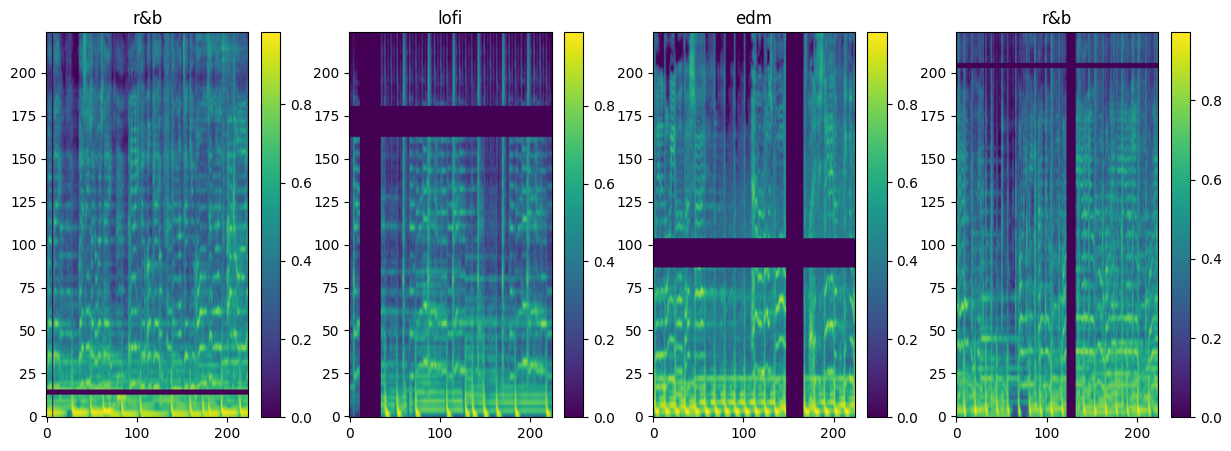

Visualizing Validation Data...
Batch Mean: -0.4461, Std: 1.2017
Batch Min: -2.1179, Max: 2.5746


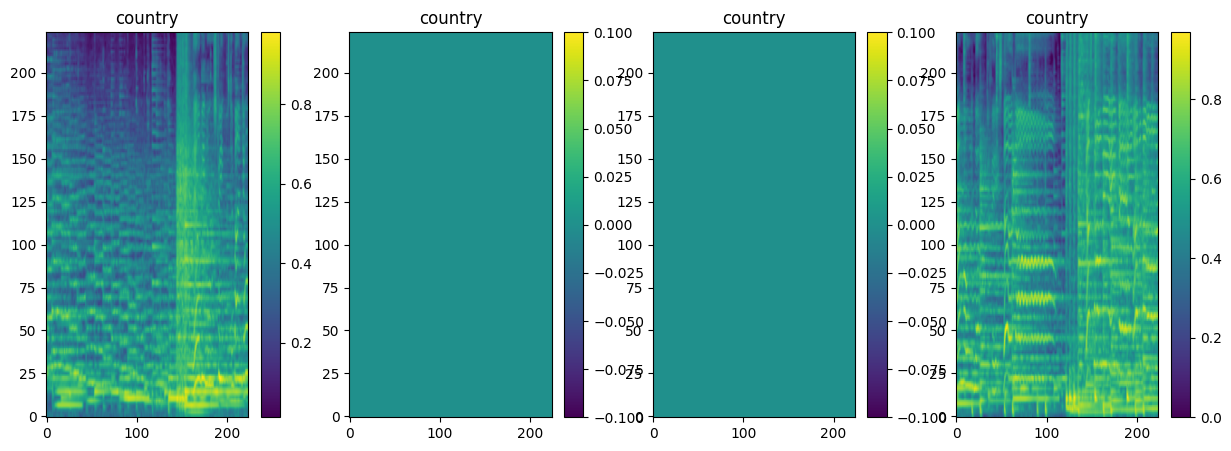

In [5]:
def show_batch(dataloader):
    inputs, classes = next(iter(dataloader))
    print(f'Batch Mean: {inputs.mean():.4f}, Std: {inputs.std():.4f}')
    print(f'Batch Min: {inputs.min():.4f}, Max: {inputs.max():.4f}')
    inputs_vis = inputs.clone()
    mean = torch.tensor([0.485, 0.456, 0.406]).view(1, 3, 1, 1)
    std = torch.tensor([0.229, 0.224, 0.225]).view(1, 3, 1, 1)
    inputs_vis = inputs_vis * std + mean
    fig, axes = plt.subplots(1, 4, figsize=(15, 5))
    for i in range(4):
        ax = axes[i]
        img = inputs_vis[i][0].numpy()
        im = ax.imshow(img, origin='lower', aspect='auto', cmap='viridis')
        ax.set_title(le.inverse_transform([classes[i]])[0])
        plt.colorbar(im, ax=ax)
    plt.show()

print('Visualizing Training Data...')
show_batch(train_loader)
print('Visualizing Validation Data...')
show_batch(val_loader)

In [6]:
# Load pretrained MobileNetV2 and adapt classifier
mobilenet = models.mobilenet_v2(weights=models.MobileNet_V2_Weights.IMAGENET1K_V1)

# Freeze all features first
for param in mobilenet.features.parameters():
    param.requires_grad = False

in_features = mobilenet.classifier[1].in_features
mobilenet.classifier = nn.Sequential(
    nn.Dropout(0.4),
    nn.Linear(in_features, 512),
    nn.ReLU(),
    nn.Dropout(0.3),
    nn.Linear(512, num_classes)
)

# Optionally unfreeze last few blocks for fine-tuning
for name, param in mobilenet.features.named_parameters():
    if '18' in name or '17' in name:  # last stages
        param.requires_grad = True

mobilenet = mobilenet.to(device)

trainable_params = sum(p.numel() for p in mobilenet.parameters() if p.requires_grad)
total_params = sum(p.numel() for p in mobilenet.parameters())
print(f'Total Parameters: {total_params:,}')
print(f'Trainable Parameters: {trainable_params:,}')
print(f'Percentage Trainable: {100 * trainable_params / total_params:.2f}%')

criterion = nn.CrossEntropyLoss()
optimizer = optim.AdamW(filter(lambda p: p.requires_grad, mobilenet.parameters()), lr=LEARNING_RATE, weight_decay=0.05)
scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=NUM_EPOCHS)
scaler = torch.amp.GradScaler('cuda')

Downloading: "https://download.pytorch.org/models/mobilenet_v2-b0353104.pth" to C:\Users\LOQ/.cache\torch\hub\checkpoints\mobilenet_v2-b0353104.pth
100%|██████████| 13.6M/13.6M [00:05<00:00, 2.56MB/s]



Total Parameters: 2,884,361
Trainable Parameters: 1,546,569
Percentage Trainable: 53.62%


In [7]:
def train_model(model, criterion, optimizer, scheduler, num_epochs=25, patience=5):
    train_acc_history = []
    val_acc_history = []
    best_model_wts = model.state_dict()
    best_acc = 0.0
    epochs_no_improve = 0

    for epoch in range(num_epochs):
        print(f'Epoch {epoch+1}/{num_epochs}')
        print('-' * 10)
        for phase in ['train', 'val']:
            if phase == 'train':
                model.train()
                dataloader = train_loader
            else:
                model.eval()
                dataloader = val_loader

            running_loss = 0.0
            running_corrects = 0

            for inputs, labels in tqdm(dataloader, desc=phase):
                inputs = inputs.to(device)
                labels = labels.to(device)
                optimizer.zero_grad()
                with torch.set_grad_enabled(phase == 'train'):
                    with torch.amp.autocast('cuda', enabled=(device.type == 'cuda')):
                        outputs = model(inputs)
                        _, preds = torch.max(outputs, 1)
                        loss = criterion(outputs, labels)
                    if phase == 'train':
                        scaler.scale(loss).backward()
                        scaler.step(optimizer)
                        scaler.update()
                running_loss += loss.item() * inputs.size(0)
                running_corrects += torch.sum(preds == labels.data)

            if phase == 'train':
                scheduler.step()

            epoch_loss = running_loss / len(dataloader.dataset)
            epoch_acc = running_corrects.double() / len(dataloader.dataset)
            print(f'{phase} Loss: {epoch_loss:.4f} Acc: {epoch_acc:.4f}')

            if phase == 'train':
                train_acc_history.append(epoch_acc.item())
            else:
                val_acc_history.append(epoch_acc.item())
                if epoch_acc > best_acc:
                    best_acc = epoch_acc
                    best_model_wts = model.state_dict()
                    epochs_no_improve = 0
                else:
                    epochs_no_improve += 1

        print(f'Best Val Acc: {best_acc:.4f}')
        if epochs_no_improve >= patience:
            print(f'Early stopping triggered after {epoch+1} epochs!')
            break

    print(f'Best val Acc: {best_acc:4f}')
    model.load_state_dict(best_model_wts)
    return model, train_acc_history, val_acc_history

trained_mobilenet, train_hist, val_hist = train_model(mobilenet, criterion, optimizer, scheduler, num_epochs=NUM_EPOCHS, patience=5)

Epoch 1/35
----------


train: 100%|██████████| 765/765 [00:39<00:00, 19.33it/s]


train Loss: 1.5414 Acc: 0.4495


val: 100%|██████████| 152/152 [00:05<00:00, 26.94it/s]


val Loss: 1.2608 Acc: 0.5440
Best Val Acc: 0.5440
Epoch 2/35
----------


...

val Loss: 1.3018 Acc: 0.5909
Best Val Acc: 0.6053
Epoch 15/35
----------


train: 100%|██████████| 765/765 [00:35<00:00, 21.71it/s]


train Loss: 0.8268 Acc: 0.7089


val: 100%|██████████| 152/152 [00:05<00:00, 28.73it/s]

val Loss: 1.3369 Acc: 0.5988
Best Val Acc: 0.6053
Early stopping triggered after 15 epochs!
Best val Acc: 0.605350


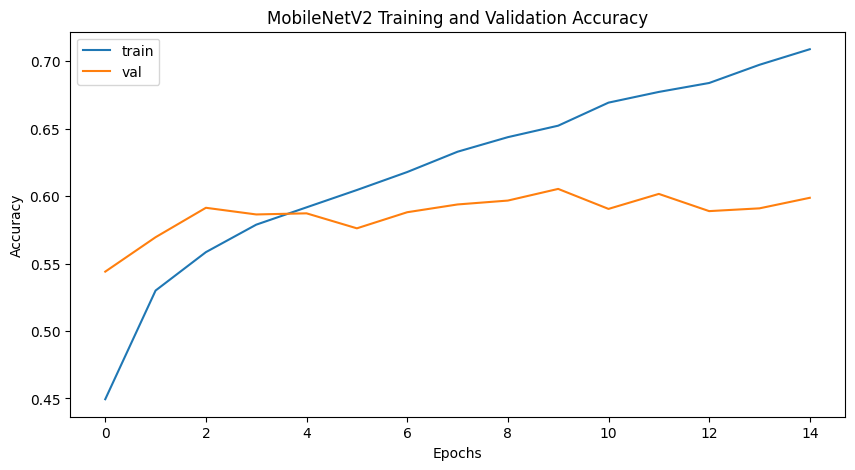

In [8]:
plt.figure(figsize=(10, 5))
plt.title('MobileNetV2 Training and Validation Accuracy')
plt.plot(train_hist, label='train')
plt.plot(val_hist, label='val')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.show()

In [ ]:
torch.save(trained_mobilenet.state_dict(), 'mobilenetv2.pth')
print('MobileNetV2 model saved successfully.')

MobileNetV2 model saved successfully.


C:\Users\LOQ\AppData\Local\Temp\ipykernel_10896\4095177169.py:5: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  mobilenet.load_state_dict(torch.load('mobilenet_v2_genre.pth')

Evaluating MobileNetV2 on Test Set...


Testing: 100%|██████████| 102/102 [00:04<00:00, 20.55it/s]



Classification Report:
              precision    recall  f1-score   support

     country       0.53      0.65      0.58       192
         edm       0.53      0.56      0.55       215
      hiphop       0.58      0.59      0.58       163
        jazz       0.86      0.83      0.85        99
        kpop       0.53      0.52      0.52       198
        lofi       0.97      0.86      0.91       174
         pop       0.33      0.34      0.34       196
         r&b       0.58      0.52      0.55       182
        rock       0.60      0.57      0.58       206

    accuracy                           0.59      1625
   macro avg       0.61      0.60      0.61      1625
weighted avg       0.59      0.59      0.59      1625



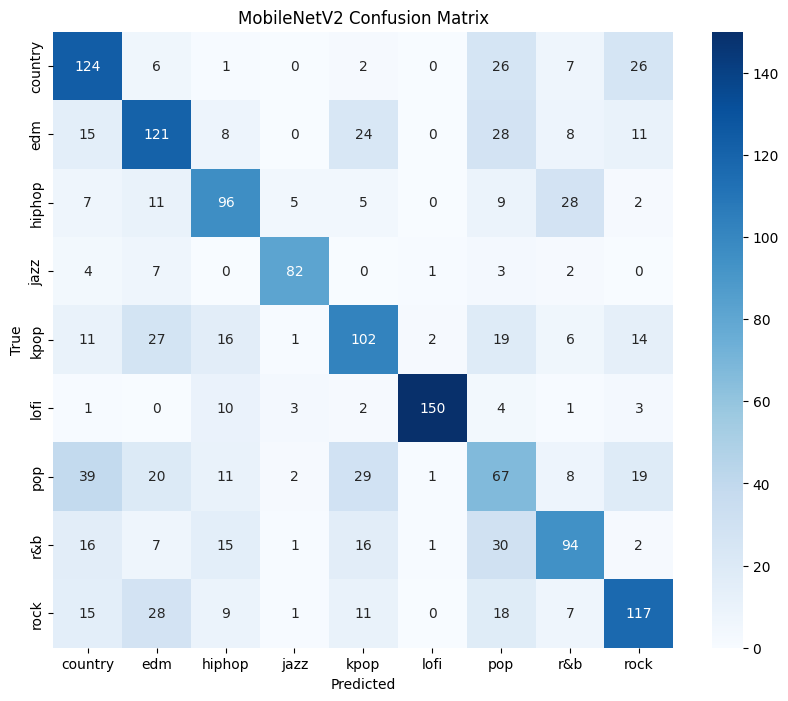

In [ ]:
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns

mobilenet.eval()
mobilenet.load_state_dict(torch.load('mobilenetv2.pth'))

all_preds = []
all_labels = []
print('Evaluating MobileNetV2 on Test Set...')
with torch.no_grad():
    for inputs, labels in tqdm(test_loader, desc='Testing'):
        inputs = inputs.to(device)
        labels = labels.to(device)
        outputs = mobilenet(inputs)
        _, preds = torch.max(outputs, 1)
        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

correct = np.sum(np.array(all_preds) == np.array(all_labels))
accuracy = correct / len(all_labels)
print('Classification Report:')
print(classification_report(all_labels, all_preds, target_names=le.classes_))

cm = confusion_matrix(all_labels, all_preds)
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=le.classes_, yticklabels=le.classes_)
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('MobileNetV2 Confusion Matrix')
plt.show()